Project Details
Customer purchase prediction


## Data Preparation



In [6]:
from locale import normalize

import np
import pandas as pd

In [15]:
import numpy as np

df = pd.read_csv("data.csv")
df.replace("?", np.nan, inplace = True)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,...,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,NaN,5.2006,...,no,no,no,8,yes,0,0.00,NaN,NaN,NaN
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,...,yes,no,no,13,yes,0,0.00,NaN,NaN,NaN
2,49923,no,yes,no,4/3/1972,yes,no,check,NaN,12.2007,...,no,no,no,3,yes,0,0.00,NaN,NaN,NaN
3,49924,no,no,yes,8/1/1966,yes,no,check,NaN,1.2007,...,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,...,no,no,no,16,yes,0,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,49821,no,yes,no,3/3/1981,yes,no,check,NaN,6.2005,...,no,no,no,10,no,1,40.83,3/9/2002,0,3
29996,49824,no,yes,no,2/21/1972,no,no,credit_card,Eurocard,5.2005,...,no,no,no,10,no,2,52.84,6/3/2001,0,0
29997,49825,no,yes,no,6/11/1980,no,no,credit_card,Eurocard,11.2006,...,no,no,no,6,yes,0,0.00,NaN,NaN,NaN
29998,49828,no,yes,no,12/4/1980,no,no,credit_card,Visa,4.2005,...,no,no,no,6,no,1,42.92,7/1/2001,0,0


In [16]:
print(df.shape)


(30000, 44)


In [17]:
print(df.head())

   ORDER_ID CLASS B_EMAIL B_TELEFON B_BIRTHDATE FLAG_LRIDENTISCH  \
0     49917    no     yes        no   1/17/1973              yes   
1     49919    no     yes       yes   12/8/1970               no   
2     49923    no     yes        no    4/3/1972              yes   
3     49924    no      no       yes    8/1/1966              yes   
4     49927    no     yes       yes  12/21/1969              yes   

  FLAG_NEWSLETTER    Z_METHODE Z_CARD_ART  Z_CARD_VALID  ... FAIL_RPLZ  \
0             yes        check        NaN        5.2006  ...        no   
1              no  credit_card       Visa       12.2007  ...       yes   
2              no        check        NaN       12.2007  ...        no   
3              no        check        NaN        1.2007  ...        no   
4              no  credit_card   Eurocard       12.2006  ...        no   

   FAIL_RORT FAIL_RPLZORTMATCH SESSION_TIME  NEUKUNDE  AMOUNT_ORDER_PRE  \
0         no                no            8       yes                 0

In [18]:
print(df.dtypes)

ORDER_ID               int64
CLASS                    str
B_EMAIL                  str
B_TELEFON                str
B_BIRTHDATE              str
FLAG_LRIDENTISCH         str
FLAG_NEWSLETTER          str
Z_METHODE                str
Z_CARD_ART               str
Z_CARD_VALID         float64
Z_LAST_NAME              str
VALUE_ORDER          float64
WEEKDAY_ORDER            str
TIME_ORDER               str
AMOUNT_ORDER           int64
ANUMMER_01             int64
ANUMMER_02               str
ANUMMER_03               str
ANUMMER_04               str
ANUMMER_05               str
ANUMMER_06               str
ANUMMER_07               str
ANUMMER_08               str
ANUMMER_09               str
ANUMMER_10               str
CHK_LADR                 str
CHK_RADR                 str
CHK_KTO                  str
CHK_CARD                 str
CHK_COOKIE               str
CHK_IP                   str
FAIL_LPLZ                str
FAIL_LORT                str
FAIL_LPLZORTMATCH        str
FAIL_RPLZ     

In [19]:
print(df.isnull().sum())

ORDER_ID                 0
CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
S

In [20]:
print(df.describe())

           ORDER_ID  Z_CARD_VALID   VALUE_ORDER  AMOUNT_ORDER     ANUMMER_01  \
count  30000.000000  30000.000000  30000.000000  30000.000000   30000.000000   
mean   25032.612933      6.680567     43.968058      1.442200  331860.254033   
std    14422.306098      3.468332     35.709431      0.921496  147310.846584   
min        1.000000      1.200500      5.200000      1.000000  100061.000000   
25%    12518.750000      3.200700     17.990000      1.000000  204159.000000   
50%    25095.500000      6.200700     34.500000      1.000000  401241.000000   
75%    37520.250000     10.200500     57.800000      2.000000  407703.000000   
max    50000.000000     12.200700    361.200000      9.000000  609725.000000   

       SESSION_TIME  AMOUNT_ORDER_PRE  VALUE_ORDER_PRE  
count  30000.000000      30000.000000     30000.000000  
mean       8.577900          0.606700        29.875652  
std        3.863448          0.765616        57.382732  
min        1.000000          0.000000         0.000

In [21]:
print(f'Duplicate Rows: {df.duplicated().sum()}')

Duplicate Rows: 0


## Drop columns

In [39]:
df2 = df.drop('ORDER_ID', axis = 1)
print(df2.isnull().sum())

CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
SESSION_TIME             0
N

## PERFORMING FEATURE EXPLORATION V1

In [38]:
df2['CLASS'].value_counts(normalize = True).mul(100).round(2).astype(str) + '%'

CLASS
no     94.18%
yes     5.82%
Name: proportion, dtype: str

In [35]:
(pd.crosstab(df2['B_EMAIL'], df2['CLASS'], normalize='index')
 .mul(100)
 .round(2)
 .astype(str) + '%')

CLASS,no,yes
B_EMAIL,,
no,90.18%,9.82%
yes,95.19%,4.81%


In [44]:
phone_risk_rate = df2.groupby("B_TELEFON")['CLASS'].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'
print(phone_risk_rate)

B_TELEFON
no      6.3%
yes    3.13%
Name: yes, dtype: str


In [47]:
risk_missing_birth = (
    df2.groupby(df2["B_BIRTHDATE"].isna())["CLASS"]
       .value_counts(normalize=True)
       .unstack()["yes"]
       .mul(100)
       .round(2)
       .astype(str) + '%'
)

print(risk_missing_birth)


B_BIRTHDATE
False     5.8%
True     6.02%
Name: yes, dtype: str


In [49]:
df2["B_BIRTHDATE"] = pd.to_datetime(df2["B_BIRTHDATE"])
df2["B_BIRTHDATE"].head()

0   1973-01-17
1   1970-12-08
2   1972-04-03
3   1966-08-01
4   1969-12-21
Name: B_BIRTHDATE, dtype: datetime64[us]

In [64]:
df2["AGE"] = 2007 - df2["B_BIRTHDATE"].dt.year

In [65]:
df2["AGE"].describe()

count    27058.000000
mean        36.417215
std          9.633060
min         21.000000
25%         29.000000
50%         35.000000
75%         43.000000
max         73.000000
Name: AGE, dtype: float64

<Axes: >

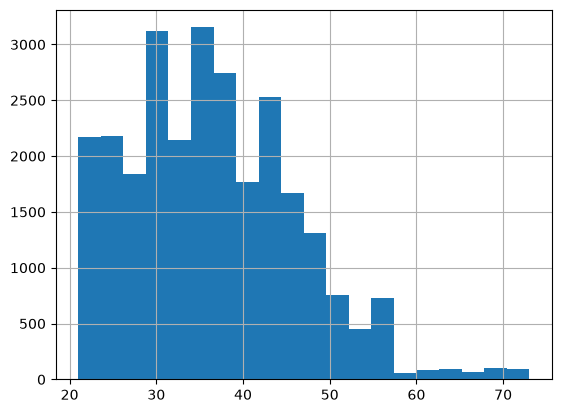

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
df2["AGE"].hist(bins=20)

In [67]:
df2["AGE_GROUP"] = pd.cut(
    df2["AGE"],
    bins=[0,18,30,45,60,100],
    labels=["<18","18-30","31-45","46-60","60+"]
)

In [68]:
df2["AGE_GROUP"] = (
    df2["AGE_GROUP"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)

In [69]:
(
df2.groupby("AGE_GROUP")["CLASS"]
.value_counts(normalize=True)
.unstack()["yes"]
.mul(100)
.round(2)
)

AGE_GROUP
18-30      5.83
31-45      5.53
46-60      6.66
60+        5.64
Missing    6.02
Name: yes, dtype: float64

In [72]:
df2["AGE_GROUP"].value_counts(dropna=False)

AGE_GROUP
31-45      14172
18-30       8305
46-60       4173
Missing     2942
60+          408
<18            0
Name: count, dtype: int64

In [ ]:
df2 = df.drop("B_BIRTHDATE", axis = 1)

In [80]:
df.groupby("FLAG_LRIDENTISCH")["CLASS"].value_counts(normalize=True).unstack()["yes"].mul(100).round(2)

FLAG_LRIDENTISCH
no     5.71
yes    5.87
Name: yes, dtype: float64

In [81]:
df2["FLAG_LRIDENTISCH"].value_counts(normalize=True).mul(100).round(2)

FLAG_LRIDENTISCH
yes    70.52
no     29.48
Name: proportion, dtype: float64

In [82]:
df2.isnull().sum()

CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
SESSION_TIME             0
N

In [84]:
df2.groupby("FLAG_NEWSLETTER")["CLASS"].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'

FLAG_NEWSLETTER
no     5.96%
yes    2.61%
Name: yes, dtype: str

In [85]:
df2["FLAG_NEWSLETTER"].value_counts(normalize=True).mul(100).round(2)

FLAG_NEWSLETTER
no     95.91
yes     4.09
Name: proportion, dtype: float64

In [93]:
table = pd.crosstab(
    df["FLAG_NEWSLETTER"],
    df["B_EMAIL"]
)
table.columns = ["noemailsubmitted=no", "yesmail=yes"]
print(table)

                 noemailsubmitted=no  yesmail=yes
FLAG_NEWSLETTER                                  
no                              6037        22735
yes                                0         1228


In [89]:
table = pd.crosstab(
    df["FLAG_NEWSLETTER"],
    df["NEUKUNDE"]
)

table.columns = ["NEUKUNDE=no", "NEUKUNDE=yes"]

print(table)

                 NEUKUNDE=no  NEUKUNDE=yes
FLAG_NEWSLETTER                           
no                     14348         14424
yes                      620           608


In [97]:
new_customers_risk_rate = df2.groupby("NEUKUNDE")["CLASS"].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'

print(new_customers_risk_rate)

NEUKUNDE
no     3.51%
yes    8.12%
Name: yes, dtype: str


In [98]:
df2["NEUKUNDE"].value_counts(normalize=True).mul(100).round(2)

NEUKUNDE
yes    50.11
no     49.89
Name: proportion, dtype: float64

In [100]:
new_value_risk_rate = df2.groupby("VALUE_ORDER")["CLASS"].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'

print(new_value_risk_rate)

VALUE_ORDER
5.20       8.89%
6.50       8.32%
8.50      11.64%
9.80       7.96%
9.99       8.14%
           ...  
313.49       NaN
313.59       NaN
342.00       NaN
347.10       NaN
361.20       NaN
Name: yes, Length: 2341, dtype: str


In [101]:
df2["VALUE_ORDER"].describe()

count    30000.000000
mean        43.968058
std         35.709431
min          5.200000
25%         17.990000
50%         34.500000
75%         57.800000
max        361.200000
Name: VALUE_ORDER, dtype: float64

In [112]:
df2["VALUE_ORDER_GROUP"] = pd.qcut(
    df2["VALUE_ORDER"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)
df2["VALUE_ORDER_GROUP"].value_counts()

VALUE_ORDER_GROUP
Low          7638
High         7575
Medium       7519
Very High    7268
Name: count, dtype: int64

In [114]:
df2.groupby("VALUE_ORDER_GROUP")["CLASS"].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'

VALUE_ORDER_GROUP
Low          7.54%
Medium       4.67%
High         4.99%
Very High    6.07%
Name: yes, dtype: str

In [115]:
from eda_utils import *

In [116]:
num_summary(df2, "SESSION_TIME")

count    30000.000000
mean         8.577900
std          3.863448
min          1.000000
25%          6.000000
50%          9.000000
75%         11.000000
max         24.000000
Name: SESSION_TIME, dtype: float64

<Axes: >

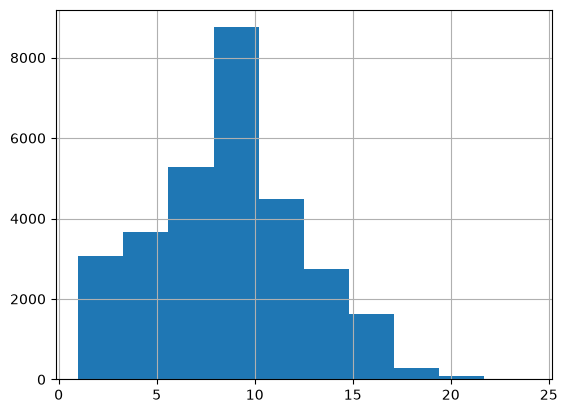

In [117]:
df2["SESSION_TIME"].hist()

In [118]:
quartile_group(df2, "SESSION_TIME")

In [119]:
risk_rate(df2, "SESSION_TIME_GROUP")

count(df2, "SESSION_TIME_GROUP")

SESSION_TIME_GROUP
Low          9277
Medium       8660
Very High    6805
High         5258
Name: count, dtype: int64

In [122]:
risk_rate(df2, "SESSION_TIME_GROUP")

SESSION_TIME_GROUP
Low          7.48
Medium       5.55
High         4.70
Very High    4.76
Name: yes, dtype: float64

In [123]:
num_summary(df2, "TIME_ORDER")

count          29980
unique          1439
top       3:51:00 PM
freq              73
Name: TIME_ORDER, dtype: object

In [124]:
df2["TIME_ORDER"].head(10)

0     9:13:00 AM
1     5:36:00 PM
2    11:13:00 AM
3     2:07:00 AM
4    11:46:00 PM
5     1:13:00 PM
6     2:43:00 PM
7     8:51:00 AM
8     4:17:00 PM
9     4:43:00 PM
Name: TIME_ORDER, dtype: str

In [125]:
df2["TIME_ORDER"] = pd.to_datetime(df2["TIME_ORDER"])

/var/folders/wq/lbl72c0568xgkvsb4rm3z9_c0000gn/T/ipykernel_30022/426495119.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2["TIME_ORDER"] = pd.to_datetime(df2["TIME_ORDER"])


In [126]:
df2["ORDER_HOUR"] = df2["TIME_ORDER"].dt.hour

In [127]:
count(df2, "ORDER_HOUR")

ORDER_HOUR
14.0    1896
11.0    1872
15.0    1726
10.0    1672
13.0    1671
9.0     1507
12.0    1475
16.0    1469
17.0    1320
8.0     1311
18.0    1264
20.0    1115
19.0    1088
7.0     1076
23.0    1019
22.0    1013
21.0     997
5.0      979
0.0      963
4.0      959
6.0      950
2.0      915
3.0      906
1.0      817
NaN       20
Name: count, dtype: int64

<Axes: >

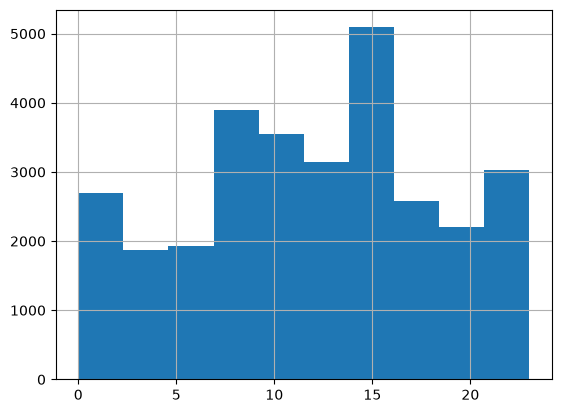

In [128]:
df2["ORDER_HOUR"].hist()

In [132]:
df2["TIME_BUCKET"] = pd.cut(
    df2["ORDER_HOUR"],
    bins=[-1,6,12,18,24],
    labels=["Night","Morning","Afternoon","Evening"]
)

In [133]:
count(df2, "TIME_BUCKET")

TIME_BUCKET
Afternoon    9346
Morning      8913
Night        6489
Evening      5232
NaN            20
Name: count, dtype: int64

In [134]:
risk_rate(df2, "TIME_BUCKET")

TIME_BUCKET
Night        6.21
Morning      5.53
Afternoon    5.85
Evening      5.77
Name: yes, dtype: float64

In [136]:
count_rate(df2, "CHK_IP")



CHK_IP
no     99.6
yes     0.4
Name: proportion, dtype: float64

In [137]:
risk_rate(df2, "CHK_IP")

CHK_IP
no      5.77
yes    18.18
Name: yes, dtype: float64

In [139]:
pd.crosstab(df2["CHK_IP"], df2["CLASS"])

CLASS,no,yes
CHK_IP,,
no,28155,1724
yes,99,22


In [140]:
risk_rate(df2, "CHK_COOKIE")
count_rate(df2, "CHK_COOKIE")

risk_rate(df2, "CHK_CARD")
count_rate(df2, "CHK_CARD")

risk_rate(df2, "CHK_KTO")
count_rate(df2, "CHK_KTO")

CHK_KTO
no     99.71
yes     0.29
Name: proportion, dtype: float64

In [141]:
print("CHK_COOKIE Risk")
print(risk_rate(df2, "CHK_COOKIE"))
print()

print("CHK_COOKIE Distribution")
print(count_rate(df2, "CHK_COOKIE"))
print()

print("CHK_CARD Risk")
print(risk_rate(df2, "CHK_CARD"))
print()

print("CHK_CARD Distribution")
print(count_rate(df2, "CHK_CARD"))
print()

print("CHK_KTO Risk")
print(risk_rate(df2, "CHK_KTO"))
print()

print("CHK_KTO Distribution")
print(count_rate(df2, "CHK_KTO"))

CHK_COOKIE Risk
CHK_COOKIE
no      5.76
yes    24.21
Name: yes, dtype: float64

CHK_COOKIE Distribution
CHK_COOKIE
no     99.68
yes     0.32
Name: proportion, dtype: float64

CHK_CARD Risk
CHK_CARD
no      5.80
yes    10.28
Name: yes, dtype: float64

CHK_CARD Distribution
CHK_CARD
no     99.64
yes     0.36
Name: proportion, dtype: float64

CHK_KTO Risk
CHK_KTO
no      5.81
yes    10.23
Name: yes, dtype: float64

CHK_KTO Distribution
CHK_KTO
no     99.71
yes     0.29
Name: proportion, dtype: float64


In [142]:
feature_summary(df2, "DATE_LORDER")

FEATURE: DATE_LORDER

Count
DATE_LORDER
NaN           15856
3/19/2001        21
6/14/2003        20
5/9/2003         20
6/27/2004        19
              ...  
3/3/2004          2
9/9/2001          2
11/12/2002        2
1/10/2003         1
10/20/2003        1
Name: count, Length: 1501, dtype: int64

Distribution (%)
DATE_LORDER
NaN           52.85
3/19/2001      0.07
6/14/2003      0.07
5/9/2003       0.07
6/27/2004      0.06
              ...  
3/3/2004       0.01
9/9/2001       0.01
11/12/2002     0.01
1/10/2003      0.00
10/20/2003     0.00
Name: proportion, Length: 1501, dtype: float64

Missing Count
15856

Missing Percentage
52.85

Risk Rate (%)
DATE_LORDER
1/1/2001      NaN
1/1/2002      NaN
1/1/2003      NaN
1/1/2004      NaN
1/1/2005    18.18
            ...  
9/8/2004    25.00
9/9/2001      NaN
9/9/2002      NaN
9/9/2003      NaN
9/9/2004      NaN
Name: yes, Length: 1500, dtype: float64


In [143]:
missing_risk(df2, "DATE_LORDER")

DATE_LORDER
False    3.64
True     7.76
Name: yes, dtype: float64

In [144]:
cross_count(
    df2,
    "NEUKUNDE",
    df2["DATE_LORDER"].isna()
)

ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

In [145]:
pd.crosstab(
    df2["NEUKUNDE"],
    df2["DATE_LORDER"].isna()
)

DATE_LORDER,False,True
NEUKUNDE,,
no,14144,824
yes,0,15032


In [146]:
df2.columns.tolist()

['CLASS',
 'B_EMAIL',
 'B_TELEFON',
 'B_BIRTHDATE',
 'FLAG_LRIDENTISCH',
 'FLAG_NEWSLETTER',
 'Z_METHODE',
 'Z_CARD_ART',
 'Z_CARD_VALID',
 'Z_LAST_NAME',
 'VALUE_ORDER',
 'WEEKDAY_ORDER',
 'TIME_ORDER',
 'AMOUNT_ORDER',
 'ANUMMER_01',
 'ANUMMER_02',
 'ANUMMER_03',
 'ANUMMER_04',
 'ANUMMER_05',
 'ANUMMER_06',
 'ANUMMER_07',
 'ANUMMER_08',
 'ANUMMER_09',
 'ANUMMER_10',
 'CHK_LADR',
 'CHK_RADR',
 'CHK_KTO',
 'CHK_CARD',
 'CHK_COOKIE',
 'CHK_IP',
 'FAIL_LPLZ',
 'FAIL_LORT',
 'FAIL_LPLZORTMATCH',
 'FAIL_RPLZ',
 'FAIL_RORT',
 'FAIL_RPLZORTMATCH',
 'SESSION_TIME',
 'NEUKUNDE',
 'AMOUNT_ORDER_PRE',
 'VALUE_ORDER_PRE',
 'DATE_LORDER',
 'MAHN_AKT',
 'MAHN_HOECHST',
 'AGE',
 'AGE_GROUP',
 'VALUE_AMOUNT_GROUP',
 'VALUE_ORDER_GROUP',
 'SESSION_TIME_GROUP',
 'ORDER_HOUR',
 'TIME_BUCKET']

In [147]:
for i, col in enumerate(df2.columns, start=1):
    print(f"{i}. {col}")

1. CLASS
2. B_EMAIL
3. B_TELEFON
4. B_BIRTHDATE
5. FLAG_LRIDENTISCH
6. FLAG_NEWSLETTER
7. Z_METHODE
8. Z_CARD_ART
9. Z_CARD_VALID
10. Z_LAST_NAME
11. VALUE_ORDER
12. WEEKDAY_ORDER
13. TIME_ORDER
14. AMOUNT_ORDER
15. ANUMMER_01
16. ANUMMER_02
17. ANUMMER_03
18. ANUMMER_04
19. ANUMMER_05
20. ANUMMER_06
21. ANUMMER_07
22. ANUMMER_08
23. ANUMMER_09
24. ANUMMER_10
25. CHK_LADR
26. CHK_RADR
27. CHK_KTO
28. CHK_CARD
29. CHK_COOKIE
30. CHK_IP
31. FAIL_LPLZ
32. FAIL_LORT
33. FAIL_LPLZORTMATCH
34. FAIL_RPLZ
35. FAIL_RORT
36. FAIL_RPLZORTMATCH
37. SESSION_TIME
38. NEUKUNDE
39. AMOUNT_ORDER_PRE
40. VALUE_ORDER_PRE
41. DATE_LORDER
42. MAHN_AKT
43. MAHN_HOECHST
44. AGE
45. AGE_GROUP
46. VALUE_AMOUNT_GROUP
47. VALUE_ORDER_GROUP
48. SESSION_TIME_GROUP
49. ORDER_HOUR
50. TIME_BUCKET


In [151]:
print(df2["MAHN_AKT"].value_counts())
print(df2["MAHN_AKT"].describe())

MAHN_AKT
0    12703
1     1182
3      133
2      126
Name: count, dtype: int64
count     14144
unique        4
top           0
freq      12703
Name: MAHN_AKT, dtype: object


In [152]:
missing_risk(df2, "MAHN_AKT")

MAHN_AKT
False    3.64
True     7.76
Name: yes, dtype: float64

In [154]:


pd.crosstab(
    df2["NEUKUNDE"],
    df2["MAHN_AKT"].isna()
)

MAHN_AKT,False,True
NEUKUNDE,,
no,14144,824
yes,0,15032


In [156]:
risk_rate(df2, "MAHN_AKT")

MAHN_AKT
0     3.41
1     3.98
2    10.32
3    16.54
Name: yes, dtype: float64

In [157]:
risk_rate(df2, "MAHN_HOECHST")

MAHN_HOECHST
0    3.20
1    3.59
2    5.75
3    8.56
Name: yes, dtype: float64

In [161]:
drop_cols = [

    "ANUMMER_01",
    "ANUMMER_02",
    "ANUMMER_03",
    "ANUMMER_04",
    "ANUMMER_05",
    "ANUMMER_06",
    "ANUMMER_07",
    "ANUMMER_08",
    "ANUMMER_09",
    "ANUMMER_10",

    "B_BIRTHDATE",

    "DATE_LORDER",

    "VALUE_AMOUNT_GROUP",
    "VALUE_ORDER_GROUP",
    "SESSION_TIME_GROUP",
    "TIME_BUCKET"
]

In [162]:
df3 = df2.drop(columns=drop_cols)

In [163]:
for i, col in enumerate(df3.columns, 1):
    print(f"{i}. {col}")

1. CLASS
2. B_EMAIL
3. B_TELEFON
4. FLAG_LRIDENTISCH
5. FLAG_NEWSLETTER
6. Z_METHODE
7. Z_CARD_ART
8. Z_CARD_VALID
9. Z_LAST_NAME
10. VALUE_ORDER
11. WEEKDAY_ORDER
12. TIME_ORDER
13. AMOUNT_ORDER
14. CHK_LADR
15. CHK_RADR
16. CHK_KTO
17. CHK_CARD
18. CHK_COOKIE
19. CHK_IP
20. FAIL_LPLZ
21. FAIL_LORT
22. FAIL_LPLZORTMATCH
23. FAIL_RPLZ
24. FAIL_RORT
25. FAIL_RPLZORTMATCH
26. SESSION_TIME
27. NEUKUNDE
28. AMOUNT_ORDER_PRE
29. VALUE_ORDER_PRE
30. MAHN_AKT
31. MAHN_HOECHST
32. AGE
33. AGE_GROUP
34. ORDER_HOUR


In [164]:
df3.isnull().sum()

CLASS                    0
B_EMAIL                  0
B_TELEFON                0
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
SESSION_TIME             0
NEUKUNDE                 0
AMOUNT_ORDER_PRE         0
VALUE_ORDER_PRE          0
MAHN_AKT             15856
MAHN_HOECHST         15856
AGE                   2942
AGE_GROUP                0
ORDER_HOUR              20
dtype: int64

# Official Feature EDA

The previous **Feature Exploration** phase focused on understanding the business meaning of each variable, evaluating feature usefulness, investigating missing values, and identifying potential target leakage. Feature selection decisions were driven by hypotheses and evidence rather than purely statistical measures.

### Key Insights from Feature Exploration

- New customers exhibited substantially higher default rates than existing customers.
- Short session durations were associated with elevated risk, suggesting possible automated or suspicious behavior.
- Repeated IP addresses, browser cookies, cards, and account numbers showed significantly higher default rates despite being rare events.
- Missing values were often informative and treated as signals rather than immediately imputed.
- Several variables were identified as identifiers, highly sparse fields, or redundant representations and were removed.
- Potential leakage variables were investigated carefully before retention.

Having established which features to retain and how missing values should be interpreted, the analysis now transitions to **Official Feature EDA**.

The purpose of this section is to:

- Examine distributions of numerical variables.
- Visualize differences between high-risk and low-risk customers.
- Identify outliers and skewness.
- Explore multivariate relationships.
- Validate assumptions before preprocessing and model development.

The goal is not simply to create charts, but to develop a deeper understanding of the customer behaviors and characteristics that drive payment default risk.

## PERFORMING OFFICIAL EDA